# Hyperparameter Optimization

In [1]:
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score
from catboost import CatBoostClassifier
from skopt.space import Integer, Real

import sys 
from datetime import datetime
import shutil
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load / Reload Selection Utility Functions

In [2]:
from utils2 import optimization as hpo

----

## Read Config File

In [3]:
config_path = Path(r'experiments')
config_filename =  "config_optimization_catboost_final.yml"
config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict


{'experiment': {'summary': 'binary classification - hyperparameter optimization (final experiment)',
  'classification_type': 'binary',
  'stage': 'hyperparameter_optimization',
  'tag': 'final',
  'verbosity': 0,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'name': 'catboost', 'code': 'CatBoost'},
 'param_space': {'iterations': {'min': 100, 'max': 500},
  'depth': {'min': 4, 'max': 10},
  'learning_rate': {'min': 0.01, 'max': 0.1},
  'l2_leaf_reg': {'min': 1, 'max': 9}},
 'optimization': {'scoring': 'roc_auc',
  'k_splits_outer': 4,
  'n_repeats_outer': 10,
  'k_splits_inner': 3,
  'n_iter': 30},
 'evaluation': {'confidence': 0.95},
 'final_training': {'k_splits_inner': 3, 'n_iter': 30}}

#### Set output directory

In [4]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\hyperparameter_optimization\CatBoost\final


#### Copy config file to output directory

In [5]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/hyperparameter_optimization/CatBoost/final/config_optimization_catboost_final.yml')

## Data Loading

In [6]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type)

dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

## Optuna Bayes Search Optimization

In [5]:
config.param_space

namespace(iterations=namespace(min=100, max=500),
          depth=namespace(min=4, max=10),
          learning_rate=namespace(min=0.01, max=0.1),
          l2_leaf_reg=namespace(min=1, max=9))

In [6]:
hpo.model_class[config.model.name]

catboost.core.CatBoostClassifier

In [7]:
config.optimization

namespace(scoring='roc_auc',
          k_splits_outer=4,
          n_repeats_outer=10,
          k_splits_inner=3,
          n_iter=30)

In [8]:
def param_space_fn(trial):
    return  {
        "iterations": trial.suggest_int(
            "iterations", 
            config.param_space.iterations.min, 
            config.param_space.iterations.max),
        "depth": trial.suggest_int(
            "depth", 
            config.param_space.depth.min, 
            config.param_space.depth.max),
        "learning_rate": trial.suggest_float(
            "learning_rate", 
            config.param_space.learning_rate.min, 
            config.param_space.learning_rate.max, 
            log=True),
        "l2_leaf_reg": trial.suggest_int(
            "l2_leaf_reg", 
            config.param_space.l2_leaf_reg.min, 
            config.param_space.l2_leaf_reg.max),
    }


In [9]:
opt_results = hpo.nested_cv_youden_optuna(
    X=X.values,
    y=y.values,
    model_class=hpo.model_class[config.model.name],   # class, not an instance
    param_space_fn=param_space_fn,
    n_splits_outer=config.optimization.k_splits_outer,
    n_repeats_outer=config.optimization.n_repeats_outer,
    n_splits_inner=config.optimization.k_splits_inner,
    n_iter=config.optimization.n_iter,   # Optuna trials per outer fold
    random_state=config.experiment.random_seed,
)

In [10]:
opt_results

{'roc_auc_mean': 0.9724289772727275,
 'roc_auc_std': 0.02043489997771878,
 'youden_mean': 0.8520691287878789,
 'youden_std': 0.06811617456982277,
 'sensitivity_mean': 0.9337357954545455,
 'specificity_mean': 0.9183333333333333,
 'threshold_mean': 0.6352084424142594,
 'threshold_std': 0.122604534242776,
 'folds': [{'fold': 0,
   'roc_auc': 0.9777777777777777,
   'youden': 0.8787878787878789,
   'sensitivity': 0.8787878787878788,
   'specificity': 1.0,
   'threshold': 0.7910987837105941,
   'best_params': {'iterations': 398,
    'depth': 6,
    'learning_rate': 0.025503080154918076,
    'l2_leaf_reg': 1}},
  {'fold': 1,
   'roc_auc': 0.9959595959595959,
   'youden': 0.8666666666666667,
   'sensitivity': 1.0,
   'specificity': 0.8666666666666667,
   'threshold': 0.4922634162487495,
   'best_params': {'iterations': 323,
    'depth': 5,
    'learning_rate': 0.020555556610468626,
    'l2_leaf_reg': 1}},
  {'fold': 2,
   'roc_auc': 0.9541666666666667,
   'youden': 0.8666666666666667,
   'sens

### Calculate Confidence Interval 

In [11]:
opt_ci  = hpo.mean_confidence_interval(opt_results, config)
opt_ci

{'youden': {'mean': 0.8520691287878789,
  'std': 0.06898393152200287,
  'ci_lower': 0.8306911797547911,
  'ci_upper': 0.8734470778209666,
  'n_folds': 40},
 'roc_auc': {'mean': 0.9724289772727275,
  'std': 0.02069522766985295,
  'ci_lower': 0.9660155776216341,
  'ci_upper': 0.9788423769238208,
  'n_folds': 40}}

### Optimization Summary

In [12]:
opt_results_summary = {
    'youden': f'{opt_results["youden_mean"]:.3f} +/ {opt_results["youden_std"]:.3f}',
    'youden ci': f'{opt_ci["youden"]["ci_lower"]:.3f} - {opt_ci["youden"]["ci_upper"]:.3f}', 
    'roc_auc': f'{opt_results["roc_auc_mean"]:.3f} +/ {opt_results["roc_auc_std"]:.3f}',
    'roc_auc ci': f'{opt_ci["roc_auc"]["ci_lower"]:.3f} - {opt_ci["roc_auc"]["ci_upper"]:.3f}', 
    'threshold': f'{opt_results["threshold_mean"]:.3f} +/ {opt_results["threshold_std"]:.3f}',
    'specificity mean': f'{opt_results["specificity_mean"]:.3f}',
    'sensitivity mean': f'{opt_results["sensitivity_mean"]:.3f}',
}

opt_results_df = pd.DataFrame(opt_results_summary, index=['value']).T
opt_results_df

,value
youden,0.852 +/ 0.068
youden ci,0.831 - 0.873
roc_auc,0.972 +/ 0.020
roc_auc ci,0.966 - 0.979
threshold,0.635 +/ 0.123
specificity mean,0.918
sensitivity mean,0.934


 -----

## Train final model on ALL data

In [7]:
catboost_model = CatBoostClassifier(
    verbose=0,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=config.experiment.random_seed, 
    thread_count=-1
)

In [8]:
param_space = {
    'iterations': Integer(
        config.param_space.iterations.min, 
        config.param_space.iterations.max),
    'depth': Integer(
        config.param_space.depth.min, 
        config.param_space.depth.max),
    'learning_rate': Real(
        config.param_space.learning_rate.min, 
        config.param_space.learning_rate.max, 
        prior='log-uniform'),  # log-uniform better for LR
    'l2_leaf_reg': Real(
        config.param_space.l2_leaf_reg.min, 
        config.param_space.l2_leaf_reg.max, 
        prior='uniform'),
}

In [9]:
config.final_training

namespace(k_splits_inner=3, n_iter=30)

In [10]:
final_model, best_params = hpo.train_final_model(
    X=X.values, 
    y=y.values, 
    model=catboost_model,
    param_space=param_space,
    n_splits_inner=config.final_training.k_splits_inner,
    n_iter=config.final_training.n_iter, 
    random_state=config.experiment.random_seed, 
    n_jobs=1
)

In [11]:
print(best_params) 

OrderedDict({'depth': 4, 'iterations': 500, 'l2_leaf_reg': 4.930340353636142, 'learning_rate': 0.032559471569963375})


 -----

### Final Model Sample Prediction

In [96]:
def test_model(model, threshold, Xnew, ynew, uses_proba=False):
    if uses_proba:
        ypredproba = model.predict(Xnew)
        ypred = (ypredproba > threshold).astype(int)
    else:
        ypred, ypredproba = hpo.model_predict(Xnew, model, threshold)

    cm = confusion_matrix(ynew, ypred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    youden_test = (
        sensitivity + specificity - 1
        if not (np.isnan(sensitivity) or np.isnan(specificity))
        else np.nan
    )
    roc_auc = (
        roc_auc_score(ynew, ypredproba)
        if len(np.unique(ynew)) > 1
        else np.nan
    )

    print(cm)
    print('youden: ', youden_test)
    print('roc_auc: ', roc_auc)
    return youden_test, roc_auc

In [111]:
# 0.63 is the mean threshold, we just hardcode here
test_model(final_model, 0.63, X, y)

[[ 60   0]
 [  0 130]]
youden:  1.0
roc_auc:  1.0


(1.0, 1.0)

In [115]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
test_model(final_model, 0.63, X_test, y_test)

[[11  0]
 [ 0 37]]
youden:  1.0
roc_auc:  1.0


(1.0, 1.0)

 -----

### Save artifacts and metrics

#### Final Model

In [97]:
model_version = datetime.now().strftime("%Y%m%d-%H%M")
model_version

'20260313-1533'

In [98]:
final_model_dict = {
    'name': config.model.name,
    'model': final_model,
    'version' : model_version,
    'best_params': best_params,
    'threshold' : threshold_mean,
    'youden' : final_model_youden, 
    'roc_auc' : final_model_roc_auc,
    'n_splits_inner' : config.final_training.k_splits_inner,
    'n_iter' : config.final_training.n_iter, 
}

In [99]:
model_version

'20260313-1533'

In [100]:
joblib.dump(final_model_dict, outputdir / f"final_model_v{model_version}.joblib");


#### Metrics

In [ ]:
joblib.dump(opt_results, outputdir / "optimization_results.joblib");
opt_results_df.to_csv(outputdir / "optimization_results_summary.csv")

### Load Saved Artifacts and Verify

In [101]:
loaded_optimization_results = joblib.load(outputdir / "optimization_results.joblib")
loaded_optimization_results

{'roc_auc_mean': 0.9724289772727275,
 'roc_auc_std': 0.02043489997771878,
 'youden_mean': 0.8520691287878789,
 'youden_std': 0.06811617456982277,
 'sensitivity_mean': 0.9337357954545455,
 'specificity_mean': 0.9183333333333333,
 'threshold_mean': 0.6352084424142594,
 'threshold_std': 0.122604534242776,
 'folds': [{'fold': 0,
   'roc_auc': 0.9777777777777777,
   'youden': 0.8787878787878789,
   'sensitivity': 0.8787878787878788,
   'specificity': 1.0,
   'threshold': 0.7910987837105941,
   'best_params': {'iterations': 398,
    'depth': 6,
    'learning_rate': 0.025503080154918076,
    'l2_leaf_reg': 1}},
  {'fold': 1,
   'roc_auc': 0.9959595959595959,
   'youden': 0.8666666666666667,
   'sensitivity': 1.0,
   'specificity': 0.8666666666666667,
   'threshold': 0.4922634162487495,
   'best_params': {'iterations': 323,
    'depth': 5,
    'learning_rate': 0.020555556610468626,
    'l2_leaf_reg': 1}},
  {'fold': 2,
   'roc_auc': 0.9541666666666667,
   'youden': 0.8666666666666667,
   'sens

In [102]:
loaded_final_model_dict = joblib.load(outputdir / f"final_model_v{model_version}.joblib")
loaded_final_model_dict

{'name': 'catboost',
 'model': <catboost.core.CatBoostClassifier at 0x1cb3d4d3860>,
 'version': '20260313-1533',
 'best_params': OrderedDict([('depth', 4),
              ('iterations', 500),
              ('l2_leaf_reg', 4.930340353636142),
              ('learning_rate', 0.032559471569963375)]),
 'threshold': 0.6352084424142594,
 'youden': 1.0,
 'roc_auc': 1.0,
 'n_splits_inner': 3,
 'n_iter': 30}

In [104]:
test_model(
    loaded_final_model_dict["model"], 
    loaded_final_model_dict["threshold"], 
    X, y) 

[[ 60   0]
 [  0 130]]
youden:  1.0
roc_auc:  1.0


(1.0, 1.0)

In [106]:
pd.read_csv(outputdir / "optimization_results_summary.csv")

,Unnamed: 0,value
0,youden,0.852 +/ 0.068
1,youden ci,0.831 - 0.873
2,roc_auc,0.972 +/ 0.020
3,roc_auc ci,0.966 - 0.979
4,threshold,0.635 +/ 0.123
5,specificity mean,0.918
6,sensitivity mean,0.934


 -----

## Appendix

## Explainability Model Selection

### Regularized Model Evaluation

In [119]:
regularized_model = CatBoostClassifier(
    depth=4,
    l2_leaf_reg=10,
    iterations=300,
    learning_rate=0.05,
    verbose=0
)
regularized_model.fit(X,y)
test_model(regularized_model, 0.63, X, y)

[[ 60   0]
 [  0 130]]
youden:  1.0
roc_auc:  1.0


(1.0, 1.0)

### Unoptimized, Train-Test-Split Model Evaluation

In [123]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

unoptimized_model = CatBoostClassifier(verbose=0)
unoptimized_model.fit(X_train.values, y_train.values)
test_model(unoptimized_model, 0.5, X_test, y_test)

[[10  1]
 [ 3 34]]
youden:  0.828009828009828
roc_auc:  0.9803439803439803


(0.828009828009828, 0.9803439803439803)

### Optimized, Train-Test-Split Model Evaluation

In [124]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

optsplit_model, optsplit_best_params = hpo.train_final_model(
    X=X_train.values, 
    y=y_train.values, 
    model=catboost_model,
    param_space=param_space,
    n_splits_inner=config.final_training.k_splits_inner,
    n_iter=config.final_training.n_iter, 
    random_state=config.experiment.random_seed, 
    n_jobs=1
)

In [ ]:
optsplit_model = CatBoostClassifier(**optsplit_best_params, verbose=0, njobs=-1)
optsplit_model.fit(X_train.values, y_train.values)
test_model(unoptimized_model, 0.63, X_test, y_test)

[[10  1]
 [ 3 34]]
youden:  0.828009828009828
roc_auc:  0.9803439803439803


(0.828009828009828, 0.9803439803439803)

*We will use this methodology for generating counterfactuals, but we will do it for 4 folds*

### Distilled Model

#### Ridge

In [125]:
from sklearn.linear_model import Ridge

# probabilities from CatBoost
y_soft = final_model.predict_proba(X)[:,1]

distilled_model_ridge = Ridge()
distilled_model_ridge.fit(X, y_soft)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [126]:
test_model(distilled_model_ridge, threshold_mean, X, y, True)

[[ 57   3]
 [ 15 115]]
youden:  0.8346153846153845
roc_auc:  0.9776923076923076


(0.8346153846153845, 0.9776923076923076)

In [127]:
from sklearn.metrics import classification_report

y_pred_proba = distilled_model_ridge.predict(X)
y_pred = (y_pred_proba >= 0.63).astype(int)
print(classification_report(y, y_pred))

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

              precision    recall  f1-score   support

           0       0.81      0.95      0.88        60
           1       0.97      0.90      0.94       130

    accuracy                           0.92       190
   macro avg       0.89      0.93      0.91       190
weighted avg       0.92      0.92      0.92       190

TN: 57
FP: 3
FN: 13
TP: 117


#### Logistic Regression

In [128]:
from sklearn.linear_model import LogisticRegression

# probabilities from CatBoost
y_soft = final_model.predict_proba(X)[:,1]

distilled_model_logreg = LogisticRegression(max_iter=2000)
distilled_model_logreg.fit(X, y_soft > 0.5)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [129]:
test_model(distilled_model_logreg, 0.5, X, y, False)

[[ 55   5]
 [  5 125]]
youden:  0.8782051282051282
roc_auc:  0.9874358974358974


(0.8782051282051282, 0.9874358974358974)

### Surrogate Model

In [130]:
from sklearn.linear_model import LogisticRegression

surrogate_model = LogisticRegression(
    penalty="l2",
    C=0.1,
    class_weight="balanced",
    max_iter=1000
)

surrogate_model.fit(X, y)
surrogate_model_youden, final_model_roc_auc = test_model(surrogate_model, 0.5, X, y, False)

[[ 57   3]
 [  7 123]]
youden:  0.8961538461538461
roc_auc:  0.9761538461538461


In [131]:
ypredproba = model_soft_predict_proba(X, final_model)
ypredproba
#ypredproba ypredproba > threshold


array([1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1], dtype=int64)

In [132]:
hpo_results_path = config_path /  config.experiment.classification_type / config.experiment.stage / config.model.code / config.experiment.tag / 'optimization_results.joblib'
optimization_results = joblib.load(hpo_results_path)
threshold_mean = optimization_results['threshold_mean']
threshold_mean

0.6352084424142594

In [133]:
# test_final_model(final_model, final_threshold)
final_model_youden, final_model_roc_auc = test_model(final_model, threshold_mean, X, y)

[[ 60   0]
 [  0 130]]
youden:  1.0
roc_auc:  1.0


In [134]:
pred_proba = final_model.predict_proba(X)
margin = 0.45
pred_proba[(pred_proba[:,1] > (0.5 - margin)) & (pred_proba[:,1] < (0.5 + margin)) ]

array([[0.936, 0.064],
       [0.051, 0.949],
       [0.052, 0.948]])

### Mutual Info Classification

In [135]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y)
mi_scores.shape, mi_scores

((40,),
 array([0.   , 0.091, 0.024, 0.065, 0.061, 0.023, 0.036, 0.012, 0.049,
        0.045, 0.   , 0.153, 0.   , 0.026, 0.082, 0.058, 0.323, 0.087,
        0.21 , 0.153, 0.174, 0.049, 0.278, 0.301, 0.19 , 0.294, 0.111,
        0.214, 0.184, 0.198, 0.068, 0.248, 0.314, 0.139, 0.087, 0.   ,
        0.   , 0.   , 0.093, 0.019]))

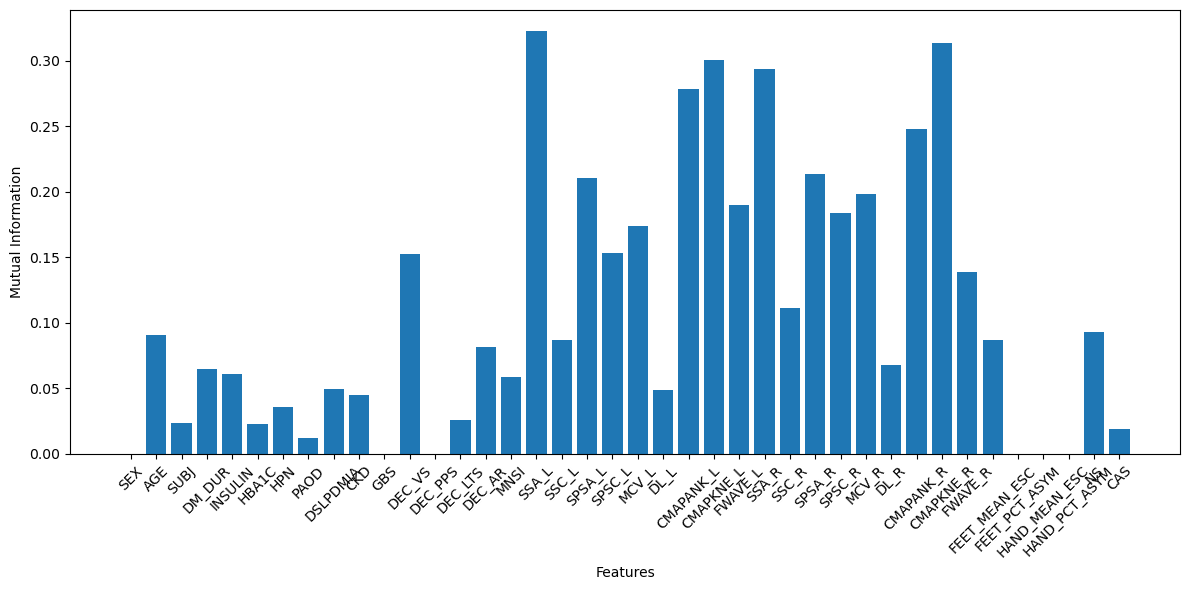

In [143]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
labels=X.columns.to_list()
plt.bar(labels, mi_scores)
plt.ylabel("Mutual Information")
plt.xticks(ticks=range(len(X.columns)), labels=X.columns.to_list(), rotation=45)
plt.xlabel("Features")
plt.tight_layout()
plt.show()

In [140]:
plt.bar?

Signature:
plt.bar(
    x: 'float | ArrayLike',
    height: 'float | ArrayLike',
    width: 'float | ArrayLike' = 0.8,
    bottom: 'float | ArrayLike | None' = None,
    *,
    align: "Literal['center', 'edge']" = 'center',
    data=None,
    **kwargs,
) -> 'BarContainer'
Docstring:
Make a bar plot.

The bars are positioned at *x* with the given *align*\ment. Their
dimensions are given by *height* and *width*. The vertical baseline
is *bottom* (default 0).

Many parameters can take either a single value applying to all bars
or a sequence of values, one for each bar.

Parameters
----------
x : float or array-like
    The x coordinates of the bars. See also *align* for the
    alignment of the bars to the coordinates.

    Bars are often used for categorical data, i.e. string labels below
    the bars. You can provide a list of strings directly to *x*.
    ``bar(['A', 'B', 'C'], [1, 2, 3])`` is often a shorter and more
    convenient notation compared to
    ``bar(range(3), [1, 2, 3], ti